# **Atividade LSTM  - Multiplas Entrdas**  

Nesta atividade, redes neurais do tipo Long Short-Term Memory (LSTM) serão empregadas para determinar o valor de fechamento das ações da Apple Inc. Para tanto, serão considerados os dados referentes aos valores de abertura, alta e baixa das ações, além do volume de negociações diário da companhia.

A base de dados utilizada neste exemplo será obtida por meio da API yFinance e conterá informações das ações da Apple Inc. (AAPL) referentes ao período compreendido entre 1º de janeiro de 2023 e 31 de dezembro de 2023.


# Base de dados Apple Inc. (AAPL)

Dados históricos de preços (abertura, fechamento, alta, baixa, volume) para diversas ações da Apple Inc.

* Close	 ->  Preço de fechamento  
* High	- >  Preço na  alta
* Low   ->  Preço  na baixa
* Open  -> Preço de abertura
* Volume - >  Volume de ações negociadas

# **1. Carregar e explorar os dados**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [ ]:
import yfinance as yf

# Baixar dados da Apple (2010-2023)
data = yf.download('AAPL', start='2023-01-01', end='2023-12-31')


/tmp/ipython-input-388035594.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2023-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Verificando as dimensões da base de dados
data.shape

(250, 5)

In [ ]:
# Verificando  a existência de dados nullos
data.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [ ]:
# Visualizando os primeiros registros da base
print(data.head(10))

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.211212  128.954561  122.324586  128.343780  112117500
2023-01-04  124.482040  126.747861  123.221065  125.004162   89113600
2023-01-05  123.161957  125.871086  122.905826  125.240599   80962700
2023-01-06  127.693581  128.353621  123.033882  124.137239   87754700
2023-01-09  128.215683  131.427242  127.959553  128.530934   70790800
2023-01-10  128.787064  129.309185  126.215853  128.324048   63896200
2023-01-11  131.506088  131.525780  128.521121  129.299374   69458900
2023-01-12  131.427246  132.264604  129.486523  131.890262   71379600
2023-01-13  132.757187  132.914813  129.703268  130.067764   57809700
2023-01-17  133.919662  135.249590  132.136565  132.826159   63646600


In [ ]:
import matplotlib.pyplot as plt

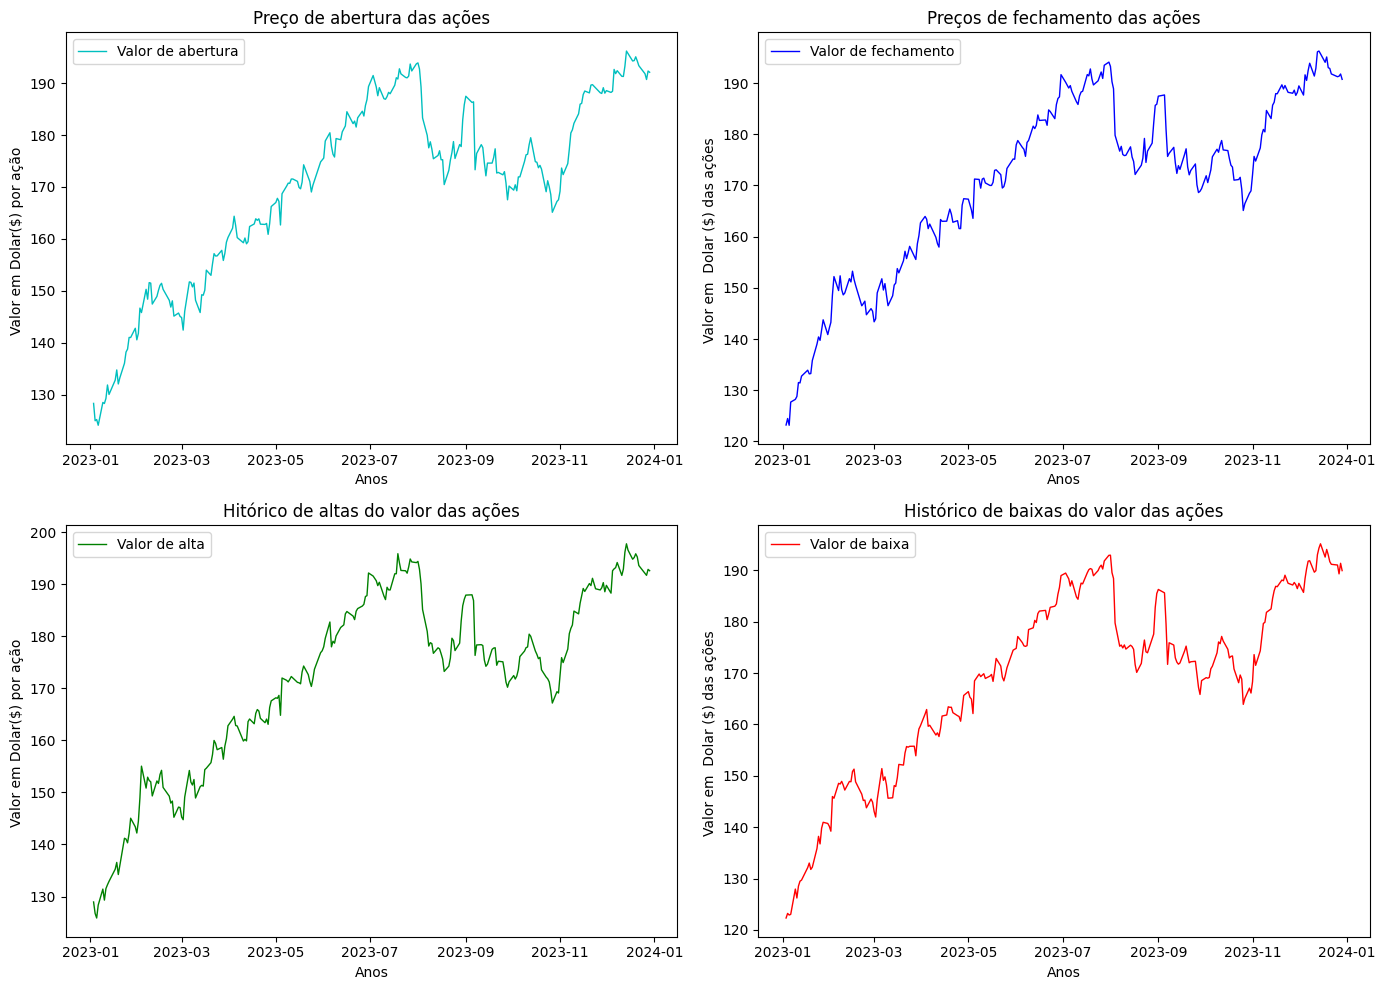

In [ ]:
# Gráfico de dispersão para os targets
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

#Abertura
ax1.plot(data.index, data.Open, 'c-', linewidth=1, label='Valor de abertura')
ax1.set_xlabel('Anos')
ax1.set_ylabel('Valor em Dolar($) por ação ')
ax1.set_title('Preço de abertura das ações')
ax1.legend( loc ='best')

#Fechamento
ax2.plot(data.index, data.Close, 'b-', linewidth=1, label='Valor de fechamento')
ax2.set_xlabel('Anos')
ax2.set_ylabel('Valor em  Dolar ($) das ações ')
ax2.set_title('Preços de fechamento das ações')
ax2.legend(loc ='best')



#Alta
ax3.plot(data.index, data.High, 'g-', linewidth=1, label='Valor de alta')
ax3.set_xlabel('Anos')
ax3.set_ylabel('Valor em Dolar($) por ação ')
ax3.set_title('Hitórico de altas do valor das ações')
ax3.legend(loc ='best')
#Baixa
ax4.plot(data.index, data.Low, 'r-', linewidth=1, label='Valor de baixa')
ax4.set_xlabel('Anos')
ax4.set_ylabel('Valor em  Dolar ($) das ações ')
ax4.set_title('Histórico de baixas do valor das ações')
ax4.legend(loc='best')

plt.tight_layout()
plt.show()

# **2 TensorFlow - Explanação de alguns paramêtros**

**Parâmentros**

 *  **Dense:** representa uma camada neural totalmente conectada (Fully Connected Layer),onde cada neurônio é conectado a todos os neurônios da camada anterior.É uma das camadas mais fundamentais em redes neurais artificiais.
 * **O Dropout:** é uma camada de regularização usada em redes neurais para evitar overfitting (sobreajuste). Ele funciona "desligando" aleatoriamente uma fração dos neurônios durante o treinamento, forçando a rede a aprender representações mais robustas e generalizáveis.
 * **Callbacks:** são ferramentas que permitem monitorar e intervir no processo de treinamento de modelos de deep learning.Eles são acionados em eventos específicos (ex: fim de uma época) e ajudam a melhorar a eficiência do treinamento, evitar overfitting e salvar os melhores modelos.
 * **EarlyStopping:**  Interromper o treinamento antecipadamente se o modelo parar de melhorar.
 * **ReduceLROnPlateau:** Reduz a taxa de aprendizado (learning rate) quando o modelo para de melhorar.
 * **ModelCheckpoint:**  Salvar o modelo (ou seus pesos) periodicamente durante o treinamento.


In [ ]:
# TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau, ModelCheckpoint


# **3. Particionando a base de dados**
* X_treinamento, y_treinamento
* X_teste, y_teste

## **3.1 Construindo a base de treinamento (X_treinamento, y_treinamento)**

In [ ]:
#Serão utilizados aproximadamente 80% dos dados para teinamento e 20% dos dados para teste
#250*0.80= 200, 50 teste

nn_base_treinamento = 200
base_treinamento =data.iloc[0:nn_base_treinamento,0:5].values

In [ ]:
base_treinamento

array([[1.23211212e+02, 1.28954561e+02, 1.22324586e+02, 1.28343780e+02,
        1.12117500e+08],
       [1.24482040e+02, 1.26747861e+02, 1.23221065e+02, 1.25004162e+02,
        8.91136000e+07],
       [1.23161957e+02, 1.25871086e+02, 1.22905826e+02, 1.25240599e+02,
        8.09627000e+07],
       [1.27693581e+02, 1.28353621e+02, 1.23033882e+02, 1.24137239e+02,
        8.77547000e+07],
       [1.28215683e+02, 1.31427242e+02, 1.27959553e+02, 1.28530934e+02,
        7.07908000e+07],
       [1.28787064e+02, 1.29309185e+02, 1.26215853e+02, 1.28324048e+02,
        6.38962000e+07],
       [1.31506088e+02, 1.31525780e+02, 1.28521121e+02, 1.29299374e+02,
        6.94589000e+07],
       [1.31427246e+02, 1.32264604e+02, 1.29486523e+02, 1.31890262e+02,
        7.13796000e+07],
       [1.32757187e+02, 1.32914813e+02, 1.29703268e+02, 1.30067764e+02,
        5.78097000e+07],
       [1.33919662e+02, 1.35249590e+02, 1.32136565e+02, 1.32826159e+02,
        6.36466000e+07],
       [1.33200516e+02, 1.3654

In [ ]:
base_treinamento.shape

(200, 5)

In [ ]:
#Definindo o normalizador
normalizador =MinMaxScaler(feature_range=(0,1))
normalizado_previsores  = MinMaxScaler(feature_range=(0,1))

In [ ]:
#Normalizando a base de treinamento
base_treinamento_normalizada =normalizador.fit_transform(base_treinamento)

In [ ]:
#Normalizando a base de treinamento

previsores_norm  =normalizado_previsores.fit_transform(base_treinamento[:,0:1])

## **3.1.1 Adequando a base de treinamento a entreda LSTM**

In [ ]:
#intervalo utilizado para relizar as previsões futuras é de 12 meses
intervalo_previsao =12

In [ ]:
X_treinamento=[] #previsores
y_treinamento =[] #preço real
for i in range(intervalo_previsao,nn_base_treinamento):
  X_treinamento.append(base_treinamento_normalizada[i-intervalo_previsao:i,0:5])
  y_treinamento.append(base_treinamento_normalizada[i,0])

# Ao final deste loop X conterá em cada uma de suas entradas,
# uma lista do 12 registros.

In [ ]:
#Convertendo X e y de Listas para Arrays
X_treinamento = np.array(X_treinamento)
y_treinamento =np.array(y_treinamento)

In [ ]:
X_treinamento.shape

(188, 12, 5)

## 3.2  **Construindo a base de teste (X_teste, y_teste)**

In [ ]:
# A base de teste será composta pelos elementos que estão
# apos a posição limite da base de treino, ou seja, após a posição 116

base_teste = data.iloc[nn_base_treinamento:,0].values

In [ ]:
base_teste

array([173.58978271, 171.03727722, 171.15597534, 171.59133911,
       169.27627563, 165.11112976, 166.42694092, 168.47485352,
       168.94976807, 172.11566162, 175.67727661, 174.76708984,
       177.31958008, 179.88197327, 180.94058228, 180.46568298,
       184.65611267, 183.0710907 , 185.68640137, 186.25106812,
       187.93513489, 187.9153595 , 189.65885925, 188.85644531,
       189.52017212, 188.19273376, 188.01437378, 188.61868286,
       187.59832764, 188.17289734, 189.45083618, 187.65774536,
       191.61044312, 190.52073669, 192.45249939, 193.87902832,
       191.37271118, 192.88838196, 196.10798645, 196.25657654,
       195.72161865, 194.05734253, 195.09751892, 193.00726318,
       192.85864258, 191.78877258, 191.243927  , 191.34298706,
       191.76895142, 190.72877502])

In [ ]:
base_teste.shape

(50,)

In [ ]:
base_teste =base_teste.reshape(-1,1)

In [ ]:
base_teste.shape

(50, 1)

## **3.2.1Adequando a base de teste a entreda LSTM**

In [ ]:
#base contem todos os dados
base_completa = data

In [ ]:
len(base_completa), len(base_teste)

(250, 50)

In [ ]:
entradas = base_completa[len(base_completa) - len(base_teste) - intervalo_previsao:].values

In [ ]:
entradas

array([[1.70562393e+02, 1.71779294e+02, 1.68999248e+02, 1.70423886e+02,
        4.95946000e+07],
       [1.71808975e+02, 1.72353116e+02, 1.69147645e+02, 1.69266361e+02,
        5.30203000e+07],
       [1.73045639e+02, 1.73579877e+02, 1.70839398e+02, 1.71937567e+02,
        4.85279000e+07],
       [1.75598129e+02, 1.76092800e+02, 1.71334057e+02, 1.71947459e+02,
        5.72667000e+07],
       [1.77082153e+02, 1.77141511e+02, 1.73926153e+02, 1.74925382e+02,
        4.23908000e+07],
       [1.76488525e+02, 1.77804351e+02, 1.76053213e+02, 1.76201623e+02,
        4.36980000e+07],
       [1.77883514e+02, 1.77932984e+02, 1.75706967e+02, 1.76300563e+02,
        4.75511000e+07],
       [1.78783829e+02, 1.80396444e+02, 1.77131616e+02, 1.78150651e+02,
        5.67431000e+07],
       [1.76943634e+02, 1.79990791e+02, 1.76241195e+02, 1.79486232e+02,
        5.14271000e+07],
       [1.76815018e+02, 1.77171181e+02, 1.74628568e+02, 1.74866015e+02,
        5.25170000e+07],
       [1.75261734e+02, 1.7651

In [ ]:
# Formato de vetor
entradas.shape

(62, 5)

In [ ]:
##Normalizando os dados de entrada
entradas_normalizadas = normalizador.transform(entradas)

In [ ]:
X_teste = []
y_teste =[]
nn_entradas =len(entradas)
for i in range(intervalo_previsao, nn_entradas):
  #print(i)
  X_teste.append(entradas_normalizadas[i - intervalo_previsao:i, 0:5])
  y_teste.append(entradas_normalizadas[i - intervalo_previsao, 0:1])



# Ao final deste loop X_teste conterá em cada uma de suas entradas,
# uma lista do 12 registros.


In [ ]:
X_teste_array =np.array(X_teste)

In [ ]:
y_teste_array =np.array(y_teste)

#4. **Construindo a Rede Neural LSTM**

In [ ]:
X_treinamento.shape[1]

12

In [ ]:
regressor = Sequential()

regressor.add(LSTM(units = 100, return_sequences=True, input_shape = (X_treinamento.shape[1], 5)))
regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 80, return_sequences=True))
regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 50, return_sequences=True))
regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 50, return_sequences=True))
regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 50, return_sequences=True))
regressor.add(Dropout(0.1))

regressor.add(LSTM(units = 30))
regressor.add(Dropout(0.1))



regressor.add(Dense(units = 1, activation = 'linear'))

regressor.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 100)        │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 80)         │        57,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 50)         │        26,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 12, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 12, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,671 (690.12 KB)

 Trainable params: 176,671 (690.12 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['mean_absolute_error'])

## **4.1 Definindo os parâmtros do callback**

In [ ]:
es =EarlyStopping(monitor='loss', min_delta=1e-10,patience=10, verbose=True)

In [ ]:
rlr =ReduceLROnPlateau(monitor='loss', factor=0.2,patience=5, verbose=True)

In [ ]:
mcp = ModelCheckpoint(filepath='pesos.keras', monitor='loss', save_best_only=True, verbose=True)

## **4.2 Realizando o treinamento da Rede LSTM**

In [ ]:
regressor.fit(X_treinamento, y_treinamento, epochs = 100, batch_size = 32,callbacks=[es,rlr,mcp])

Epoch 1/100
5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.4343 - mean_absolute_error: 0.6265
Epoch 1: loss improved from inf to 0.33706, saving model to pesos.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.4065 - mean_absolute_error: 0.6017 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0465 - mean_absolute_error: 0.1836
Epoch 2: loss improved from 0.33706 to 0.04834, saving model to pesos.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 0.0467 - mean_absolute_error: 0.1843 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0241 - mean_absolute_error: 0.1255
Epoch 3: loss improved from 0.04834 to 0.02871, saving model to pesos.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0248 - mean_absolute_error: 0.1267 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0268 - mean_absolute_error: 0.1302
Epoch 4: loss improved from 0.02871 to 0.02154, saving model to pesos.kera

# **5. Previsões**

In [ ]:
previsores_normalizados =regressor.predict(X_teste_array)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 798ms/step


In [ ]:
previsores_reais =normalizado_previsores.inverse_transform(previsores_normalizados)

In [ ]:
y_teste =normalizado_previsores.inverse_transform(y_teste_array)

In [ ]:
y_teste

array([[170.56239319],
       [171.80897522],
       [173.04563904],
       [175.59812927],
       [177.08215332],
       [176.48852539],
       [177.8835144 ],
       [178.78382874],
       [176.94363403],
       [176.8150177 ],
       [175.26173401],
       [173.96572876],
       [173.58978271],
       [171.03727722],
       [171.15597534],
       [171.59133911],
       [169.27627563],
       [165.11112976],
       [166.42694092],
       [168.47485352],
       [168.94976807],
       [172.11566162],
       [175.67727661],
       [174.76708984],
       [177.31958008],
       [179.88197327],
       [180.94058228],
       [180.46568298],
       [184.65611267],
       [183.0710907 ],
       [185.68640137],
       [186.25106812],
       [187.93513489],
       [187.9153595 ],
       [189.65885925],
       [188.85644531],
       [189.52017212],
       [188.19273376],
       [188.01437378],
       [188.61868286],
       [187.59832764],
       [188.17289734],
       [189.45083618],
       [187

In [ ]:
previsores_reais

array([[175.83038],
       [176.59224],
       [177.51732],
       [178.11447],
       [178.67946],
       [178.53954],
       [178.16087],
       [177.63965],
       [176.84436],
       [175.78955],
       [174.9859 ],
       [174.28433],
       [173.52048],
       [172.72441],
       [172.32593],
       [172.15685],
       [171.599  ],
       [171.68498],
       [172.79568],
       [174.08408],
       [175.11325],
       [176.26453],
       [177.5006 ],
       [178.71907],
       [180.4577 ],
       [181.73071],
       [182.90128],
       [183.54636],
       [184.38702],
       [185.22873],
       [185.77332],
       [186.38571],
       [186.85968],
       [187.1839 ],
       [187.46568],
       [187.54782],
       [187.44962],
       [187.2491 ],
       [186.9538 ],
       [187.00311],
       [187.00853],
       [187.10495],
       [187.46065],
       [187.69511],
       [188.12097],
       [188.61458],
       [188.5038 ],
       [188.41344],
       [188.32912],
       [188.68054]],

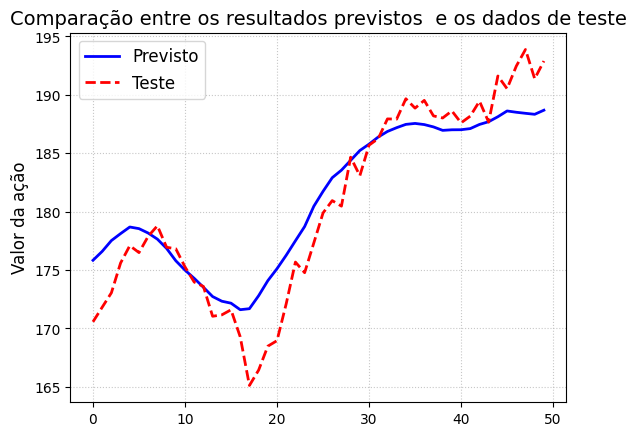

In [ ]:
# Plotando as duas curvas

plt.plot( previsores_reais, 'b-', linewidth=2, label='Previsto')      # Curva azul
plt.plot( y_teste, 'r--', linewidth=2, label='Teste')  # Curva vermelha tracejada

# Personalizando o gráfico
plt.title('Comparação entre os resultados previstos  e os dados de teste', fontsize=14)
plt.ylabel('Valor da ação', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)  # Grade pontilhada
plt.legend(fontsize=12, loc='best')  # Legenda



# Mostrando o gráfico
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
 mean_absolute_error(y_teste,previsores_reais)

2.2740924072265614